In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

merged = pd.read_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/merged/ML_merged.parquet")
print(merged.shape)
merged.head()

(66727, 55)


,OBJECT_NAME,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,NORAD_CAT_ID,BSTAR,MEAN_MOTION_DOT,SEMIMAJOR_AXIS,PERIOD,...,ry_km,rz_km,vx_km_s,vy_km_s,vz_km_s,tle_age_days,altitude_km,speed_km_s,regime,risk_label
0,EXPLORER 1,1970-03-31T00:50:24.429408,16.27546304,0.002474,33.1468,4,0.000000,0.07718844,6577.283,88.476,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LOW
1,VANGUARD 1,2026-03-20T17:10:14.647584,10.85959671,0.183694,34.2414,5,0.000161,0.00000108,8613.759,132.602,...,-3990.498411,-1923.840662,2.574536,-4.548402,3.446308,1.0,2958.830356,6.260450,MEO,LOW
2,SPUTNIK 3,1960-04-04T03:52:47.964864,16.28328133,0.008832,65.0599,8,0.000000,0.02607090,6575.177,88.434,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LOW
3,EXPLORER 4,1959-10-02T06:53:14.055072,15.51612549,0.025453,50.2549,9,0.000000,0.00892850,6790.158,92.806,...,3015.901726,-4733.148996,-6.414072,-3.952547,2.200901,24277.0,253.542836,7.849007,VLEO,LOW
4,VANGUARD 2,2026-03-21T09:09:17.498592,11.90288286,0.144571,32.8774,11,0.000462,0.00000908,8102.774,120.979,...,7840.407708,3589.239802,-5.787650,-1.342493,2.607252,0.0,2363.038666,6.488216,MEO,MEDIUM


In [14]:
merged['DECAY_EPOCH'] = pd.to_datetime(merged['DECAY_EPOCH'], errors='coerce')
merged['LAUNCH_DATE'] = pd.to_datetime(merged['LAUNCH_DATE'], errors='coerce')

# how many objects actually have decay predictions
print("objects with decay epoch:", merged['DECAY_EPOCH'].notna().sum())
print("total objects:", len(merged))

objects with decay epoch: 34353
total objects: 66727


/tmp/ipykernel_1458/2180459131.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged['LAUNCH_DATE'] = pd.to_datetime(merged['LAUNCH_DATE'], errors='coerce')


In [15]:
# instead of predicting exact days (only 77 objects)
# lets predict decay risk category for all 66k objects
# using physics — low perigee + high bstar = decaying fast

merged['BSTAR'] = pd.to_numeric(merged['BSTAR'], errors='coerce')
merged['PERIGEE'] = pd.to_numeric(merged['PERIGEE'], errors='coerce')

def decay_risk(row):
    if row['PERIGEE'] < 300 and abs(row['BSTAR']) > 0.0001:
        return 'IMMINENT'   # decaying within months
    elif row['PERIGEE'] < 500 and abs(row['BSTAR']) > 0.00001:
        return 'ELEVATED'   # decaying within years
    elif row['PERIGEE'] < 800:
        return 'MODERATE'   # LEO, will decay eventually
    else:
        return 'STABLE'     # GEO/MEO, basically forever

merged['decay_risk'] = merged.apply(decay_risk, axis=1)
print(merged['decay_risk'].value_counts())

decay_risk
IMMINENT    19699
MODERATE    19254
ELEVATED    15497
STABLE      12277
Name: count, dtype: int64


In [16]:
features = [
    'ECCENTRICITY', 'INCLINATION', 'MEAN_MOTION',
    'MEAN_MOTION_DOT', 'SEMIMAJOR_AXIS', 'PERIOD', 'APOGEE',
    'altitude_km', 'speed_km_s', 'attr_mass',
    'attr_xSectAvg', 'RCSVALUE', 'tle_age_days'
]

features = [f for f in features if f in merged.columns]
X = merged[features].apply(pd.to_numeric, errors='coerce').fillna(0)
y = merged['decay_risk']

print("X shape:", X.shape)

X shape: (66727, 13)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

    ELEVATED       0.96      0.93      0.94      3100
    IMMINENT       0.93      0.95      0.94      3940
    MODERATE       0.93      0.93      0.93      3851
      STABLE       0.99      0.98      0.99      2455

    accuracy                           0.95     13346
   macro avg       0.95      0.95      0.95     13346
weighted avg       0.95      0.95      0.95     13346



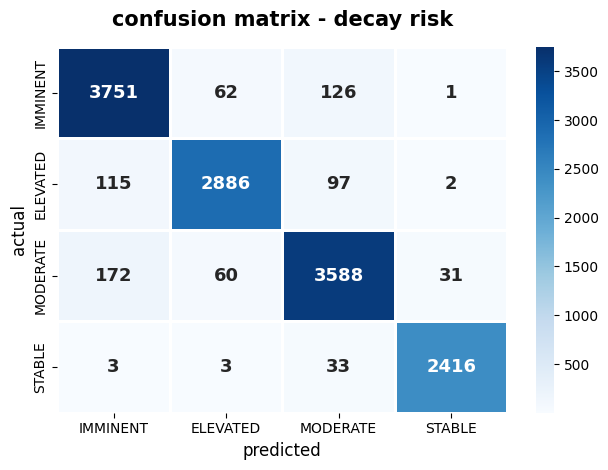

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=['IMMINENT', 'ELEVATED', 'MODERATE', 'STABLE'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['IMMINENT', 'ELEVATED', 'MODERATE', 'STABLE'],
            yticklabels=['IMMINENT', 'ELEVATED', 'MODERATE', 'STABLE'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'})

plt.title('confusion matrix - decay risk', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('actual', fontsize=12)
plt.xlabel('predicted', fontsize=12)
plt.tight_layout()
plt.show()

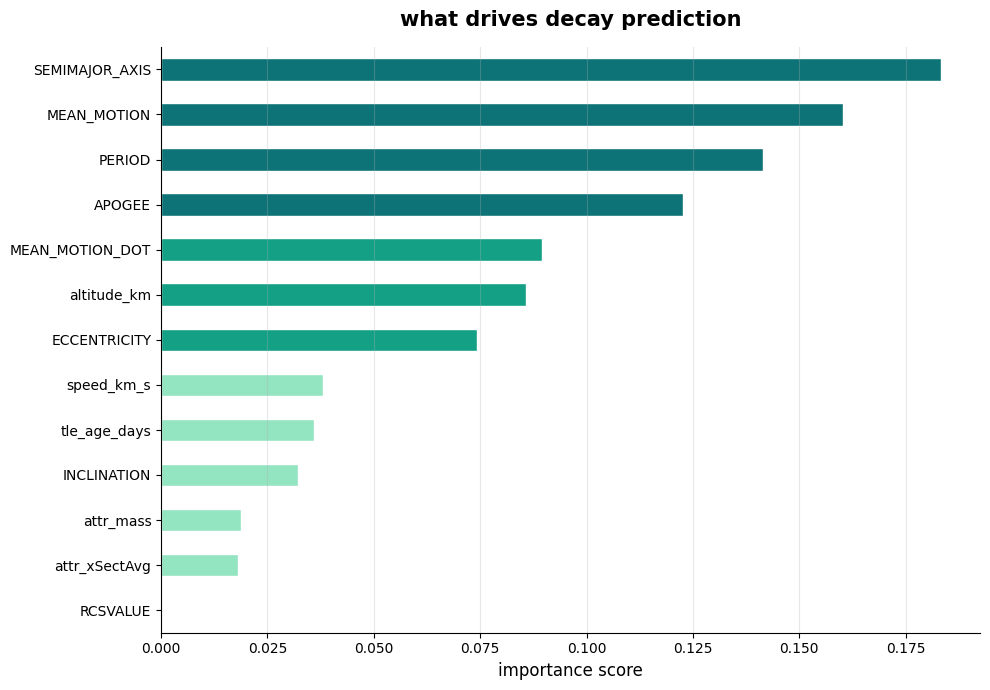

In [19]:
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#0d7377' if v > 0.10 else '#14a085' if v > 0.05 else '#93e4c1' for v in importance.values]
importance.plot(kind='barh', color=colors, edgecolor='white', ax=ax)

plt.title('what drives decay prediction', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('importance score', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()